# Importando as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path="dados/M3A1/"

### Leitura do dataset

In [7]:
dados = pd.read_excel("meteorite_landings.xlsx")

In [9]:
dados

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"
...,...,...,...,...,...,...,...,...,...,...
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.25, 17.66667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"


In [10]:
dados.to_csv("meteorite_landings.csv", index=False)

In [11]:
df = pd.read_csv("meteorite_landings.csv")
df.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


## Gráfico de linhas

### Relacionar Ano X Quantidade de meteoritos

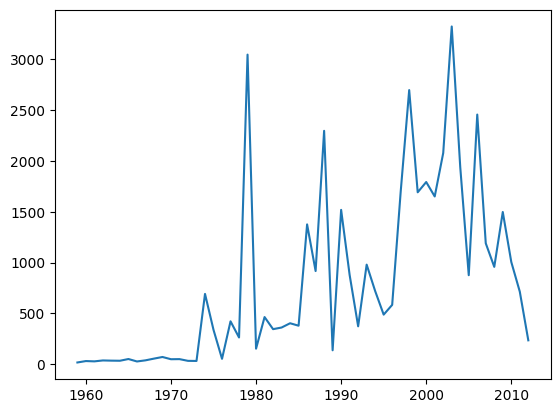

In [13]:
d = df['year'].value_counts()
met = pd.DataFrame({'ano': d.index, 'cont': d.values}).sort_values(by='ano')
met = met [(met['ano'] > 1958) & (met['ano'] < 2013)]
plt.plot(met['ano'], met['cont']) # EIXO X (met['ano'], EIXO Y(met['cont'])
plt.show()

### Mudança de cor

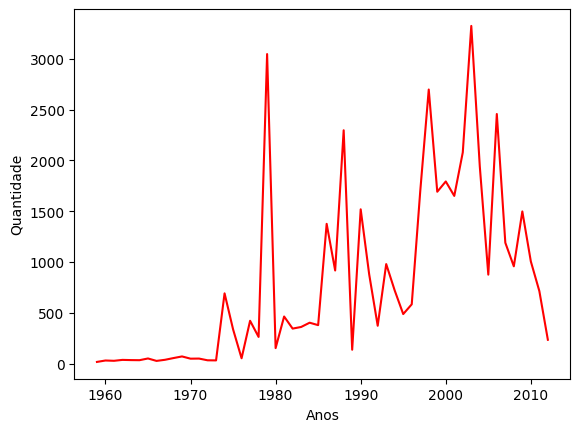

In [14]:
plt.xlabel("Anos")
plt.ylabel("Quantidade")
plt.plot(met['ano'], met['cont'], color="red") # mudando a cor da linha do gráfico ' color="red" '
plt.show()

## Gráfico de barras

### Mostrar Categorias de meteoritos X Média da massa dos meteoritos.

In [15]:
barras = df.groupby(by="recclass").agg({"mass (g)":"mean", "id":"count"}).reset_index()
barras = barras[barras["id"] > 300]

<BarContainer object of 13 artists>

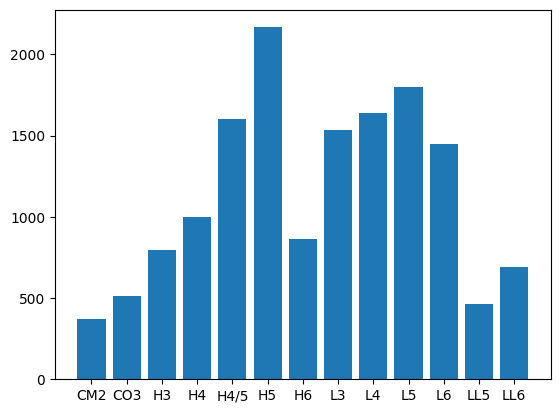

In [16]:
plt.bar(barras["recclass"], barras["mass (g)"])

### Mostrando os valores de média para cada barra

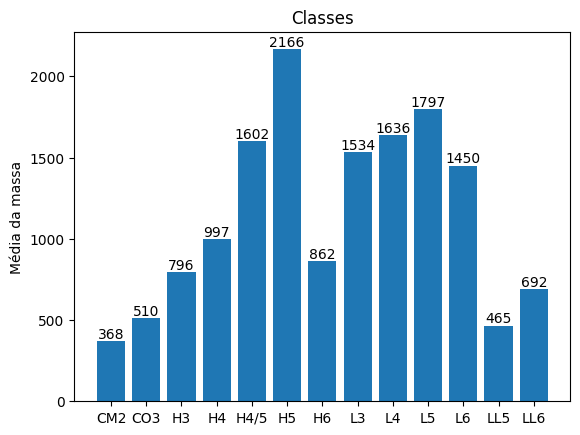

In [17]:
_, ax = plt.subplots()
bar_container = ax.bar(barras["recclass"], barras["mass (g)"])
ax.set(ylabel='Média da massa', title='Classes')
ax.bar_label(bar_container, fmt='{:.0f}')
plt.show()

### Mudando a cor do gráfico de barras

<BarContainer object of 13 artists>

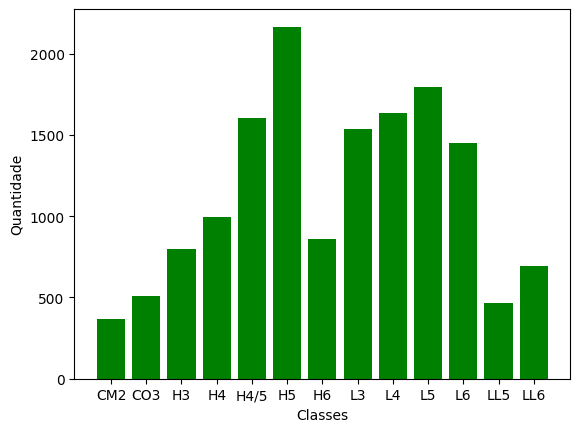

In [18]:
plt.xlabel("Classes")
plt.ylabel("Quantidade")
plt.bar(barras["recclass"], barras["mass (g)"], color="green")

## Gráfico de dispersão

### Longitude X Latitude

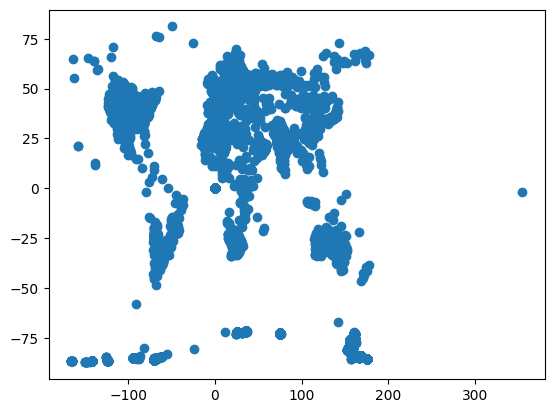

In [20]:
plt.scatter(df["reclong"], df["reclat"])

### Removendo possível outlier

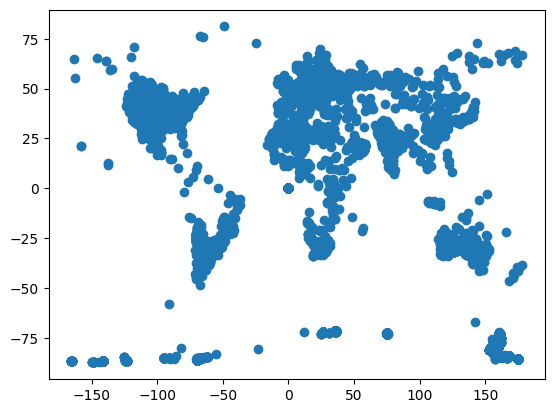

In [21]:
df_new = df[df["reclong"] < 300]
plt.scatter(df_new["reclong"], df_new["reclat"])

### Mudando a cor do gráfico de disperssão

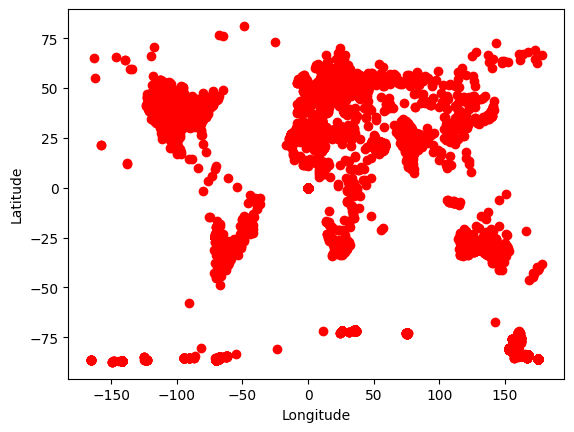

In [22]:
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.scatter(df_new["reclong"], df_new["reclat"], color="red")

## Salvando figura

### É preciso ter o código do gráfico na mesma célula

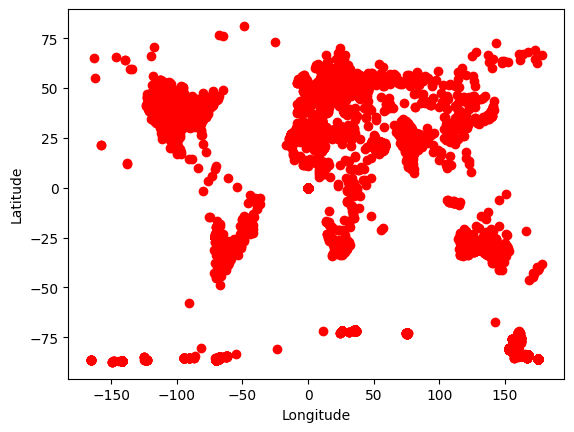

In [23]:
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.scatter(df_new["reclong"], df_new["reclat"], color="red")
plt.savefig("mapa_dos_meteoritos.jpg")